Here, we do sims where we change the soil type to keep water more or less.

See the methodology of Brian's team : what soils did they use ? 

UG : Soil water is determined by inputs (precipitation) and outputs (PrecLossFrac, percolation out of the rooting zone (controlled by SoilType) and transpiration). Tuning of soil water is done primarily with PrecLossFrac, LeakageFrac and SoilType, which assumes that transpiration is correct if the photosynthesis and growth behavior is correct. PrecLossFrac typically represents water lost where slope is sufficient for water to run off before it can enter the soil. You should calibrate for a slope condition that is flatter than average in your study area. If you have species that are found only in wetlands, you should calibrate those on a wetland ecoregion, having RunoffCapture and LeakageFrac parameter settings that produce appropriate soil saturation. RunoffCapture represents the maximum depth of standing water across the ecoregion, and LeakageFrac can be used to reflect any impermeable soil layer that reduces drainage. In lieu of empirical data to help set these parameters, tune them such that the species typically found there can survive and the hydrology mimics reality. Species that are found on both upland and lowland sites should be calibrated on both types of sites, focusing on H1 and H2 on lowland sites and H3 and H4 on upland sites.

From reese et al 2024 supp mat A (sturtevant) :

> To assess species-level response to water stress (P 5), we verified that species biomass curves simulated for moderately drained soil (e.g., very fine sandy loam) approximated the 50th percentile productivity curves estimated via FVS-ls, while those simulated for excessively drained soils (e.g., coarse sand) approximated the 5th percentile FVS-ls species biomass curve (Fig. A1). To simulate waterlogging stress, we categorized tree species according to waterlogging tolerance via the TRY database, and then calibrated tree species growth via hydrologic parameters, where intolerant species could not persist, mildly tolerant species could persist at low biomass (e.g., Fig. A1), and tolerant species had reduced growth more consistent with productivity of the 5th percentile FVS-ls species biomass curve.

Follow this methodology; but instead of using percentiles from FVS-ls, use Percentiles from the NFI instead ? But be careful to remove pixels where abundance of the species is way too low ?

Also Reese et al 2024 supp mat A for competition (if we do competition here) :

> P 5. Variation in tree species growth emerges from water stress, in a way that is consistent with the range in tree species productivity documented by FIA. 
a.	Stress-tolerant species have a narrower range in productivity than stress intolerant species, making them less competitive under optimal growing conditions and more competitive under stressed conditions (Smith and Huston 1989).
b.	Lowland sites generally enable water-logging tolerant species to establish and grow while restricting the same processes in water-logging intolerant species.


# Phase 2 💧 : Calibration of the parameters related to drought and waterlogging tolerance

In PnET-Succession, 4 parameters are related to the effect of water in the soils on tree growth : H1, H2, H3 and H4.

These parameters together define a curve relating the pressure head in the soil with the value of fWater, which is the photosythesis reduction factor linked to water. Here is an example from the user guide :

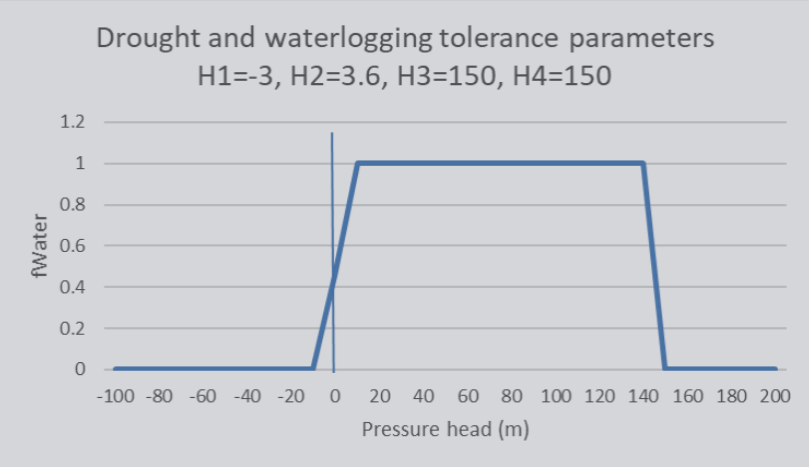

The idea of the trapezoid is that the photosynthesis of tree is overall very little affect by the amount of water present in the soil (fWater = 1, no effect on the photosynthesis); unless we arrive at thresholds of waterlogging or drought (pressure head too small or too high) where the photosynthesis will abruptly diminish. The user guide even recommends to use a value of H3 and H4 (the parameters related to high values of pressure head = drought conditions) to be the same, so that photosynthesis simply stops in drought months.

:::{warning}
Be careful about the signs (positive or negative) used for the pressure head ! I've had a lot of confusion about this.

The pressure head is a measure of water pression in the soil. It represents the following idea : If I put a cylinder in contact with the soil, will it be filled with water because there is so much water in the soil that it wants to get out (pressure, which happens during waterlogging); or will the soil instead "suck" water because it's lacking water (suction, which happens during droughts) ? 

The problem is that normally, a suction normally results in negative values of pressure head (if I had water in my cylinder, the water would go down in the soils); while pressure results in positive values (if the water pushes up into the cylinder because of pressure, how much does it pushes up ?). Pressure head is therefore the measurement, in units of distance, of how up or down the water goes when put in contact with the soil.

But in PnET-Succession, the sign convention is reversed by using the "absolute" values of pressure head. What that means is that in the case of PnET-Succession, the higher the pressure head, the more we are in drought; and vice-versa. As such, the drought parameters H3 and H4 often have positive values above 100; while the waterlogging parameters H1 and H3 are often near 0, or even negative. Keep that in mind !
:::

We sadly lack empirical data to get good estimates of these 4 parameters, and even more for many species. Although [Gustafson et al. 2025](https://bg.copernicus.org/articles/22/2499/2025/) tried to use empirical/experimental data to derive values of H1 and H2 (waterlogging).

This means that we need to calibrate, or at least make a choice about the value of these parameters.

## The different options for calibration

### Option 1 : Using parameters form previous studies

We can simply create a regression (linear or non-linear) of the score of Drought and Waterlogging tolerance acquired from [Niinemets and Valladares 2006](https://onlinelibrary.wiley.com/doi/abs/10.1890/0012-9615%282006%29076%5B0521%3ATTSDAW%5D2.0.CO%3B2) and previously published parameters (i.e. those the [user guide of PnET-Succession](./ReferencesAndData/Documentation/Gustafson2024PnETUserGuide.pdf), including those of [Gustafson et al. 2025](https://bg.copernicus.org/articles/22/2499/2025/) which have been derived from an empiical experiment. This is quick and easy, and will make sure that we use parameters similar to previous studies.

The default of this approach is that we don't do any calibration, and just re-use what have been done before. It's also deeply reliant on the hypothesis that these parameters are completly dependant on a measure as fuzzy as the "drought tolerance" or "waterlogging tolerance" of a give tree species. It also will not produce parameters that are in any way contextual to our landscape (soils, precipitations, water in the soils); we just have to hope that the model will produce soil water content that make sense for our landscape (although this can be explored).

### Option 2 : Using the method from Sturtevant et al.

The method is described in supp. material of [Reese et al. 2024](https://cdnsciencepub.com/doi/10.1139/cjfr-2024-0085) : 

> To assess species-level response to water stress (P 5), we verified that species biomass curves simulated for moderately drained soil (e.g., very fine sandy loam) approximated the 50th percentile productivity curves estimated via FVS-ls, while those simulated for excessively drained soils (e.g., coarse sand) approximated the 5th percentile FVS-ls species biomass curve (Fig. A1). To simulate waterlogging stress, we categorized tree species according to waterlogging tolerance via the TRY database, and then calibrated tree species growth via hydrologic parameters, where intolerant species could not persist, mildly tolerant species could persist at low biomass (e.g., Fig. A1), and tolerant species had reduced growth more consistent with productivity of the 5th percentile FVS-ls species biomass curve.

We could get the 50th and 5th percentile curves through the functions of Notebook 4, and do a similar experiment using the climate and soils found in the study area. This will make the parameters we derive from this more contextual to our landscape. 

The con is that the approach is quite arbitrary, choosing to lower growth by a certain amount on certain soils. It will ensure a reduced growth where there is less water in soils; but "how much" of a reduction will be quite arbitrary. It will also be a bit longuer to do.

### Options 3 : more research needed ?

There might be other opportunities or methodologies to calibrate these parameters properly that will still require a reasonable amount of time, while still allowing to calibrate many different tree species (i.e. the data we'll be using will be available for many species or locations). I haven't found anything satisfying for now, and am limited by time.

## Exploring option 1 (using regression on previously published parameters)

As I'm quite short on time to finish this calibration, I'm starting with Option 1 for now. 

First, let's look at the regression with the parameters values already catalogued in notebook 4 for the different classes of shade tolerance :

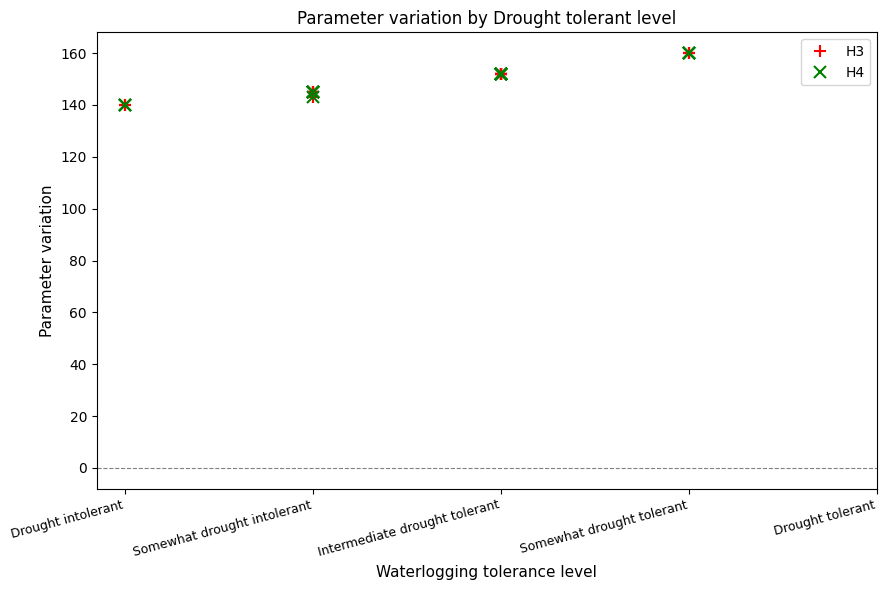

In [1]:
from functionsForCalibration import *

# Reading the table for drought tolerance variantion
# drought_tolerance_parameters = parse_parameters_bounds_table("./4.Getting_the_empirical_data.ipynb", 33)

# Reading the table for waterlogging tolerance variantion
waterlogging_tolerance_parameters = parse_parameters_bounds_table("./4.Getting_the_empirical_data.ipynb", 34)

import matplotlib.pyplot as plt

# data = waterlogging_tolerance_parameters

### VALUES FROM GUSTAFSON USER GUIDE, GATHERED BY AI BASED ON COMPILLED CSV

# Waterlogging Tolerance (H1 and H2)
# data = {
#     'H1': {
#         'Waterlogging intolerant': [0, -0.75, -4.5],
#         'Somewhat waterlogging intolerant': [-2, -3.3, -3.5, -4.5, -0.75, -0.5, -0.5, 0],
#         'Intermediate waterlogging tolerant': [0, 0],
#         'Somewhat waterlogging tolerant': [],
#         'Waterlogging tolerant': []
#     },
#     'H2': {
#         'Waterlogging intolerant': [3, 3, 1.5, 1.5, 1.5],
#         'Somewhat waterlogging intolerant': [2, 2, 2, 1.5, 1.5, 4, 4, 4],
#         'Intermediate waterlogging tolerant': [4, 4, 4, 4, 4, 4, 4, 4],
#         'Somewhat waterlogging tolerant': [],
#         'Waterlogging tolerant': []
#     }
# }

# Drought Tolerance (H3 and H4)
data = {
    'H3': {
        'Drought intolerant': [140, 140, 140],
        'Somewhat drought intolerant': [143, 145, 145, 145, 145, 145, 145],
        'Intermediate drought tolerant': [152, 152, 152, 152, 152, 152, 152, 152, 152, 152],
        'Somewhat drought tolerant': [160, 160, 160, 160],
        'Drought tolerant': []
    },
    'H4': {
        'Drought intolerant': [140, 140, 140],
        'Somewhat drought intolerant': [143, 145, 145, 145, 145, 145, 145],
        'Intermediate drought tolerant': [152, 152, 152, 152, 152, 152, 152, 152, 152, 152],
        'Somewhat drought tolerant': [160, 160, 160, 160],
        'Drought tolerant': []
    }
}


## VALUES FROM GUSTAFSON 2025 WATERLOGGING ARTICLE, GATHERED BY AI
# CONNECTED TO WATERLOGGING TOLERANCE VALUES FOR NIINEMETS DATA WITH AI

# data = {
#     'H1': {
#         'Waterlogging intolerant': [-1],
#         'Somewhat waterlogging intolerant': [-1, -1, -1, -1],
#         'Intermediate waterlogging tolerant': [-1, -1, -1, -1, -1000, -1],
#         'Somewhat waterlogging tolerant': [-500],
#         'Waterlogging tolerant': [-1]
#     },
#     'H2': {
#         'Waterlogging intolerant': [0.725],
#         'Somewhat waterlogging intolerant': [0.767, 1.704, 3.37, 0.5226],
#         'Intermediate waterlogging tolerant': [0.7164, 0.5542, 0.725, 0.808, 1, 0.869],
#         'Somewhat waterlogging tolerant': [1],
#         'Waterlogging tolerant': [0.3057]
#     }
# }

# Same, but without the -1000 and -500 outliers.

# data = {
#     'H1': {
#         'Waterlogging intolerant': [-1],
#         'Somewhat waterlogging intolerant': [-1, -1, -1, -1],
#         'Intermediate waterlogging tolerant': [-1, -1, -1, -1, -1, -1],
#         'Somewhat waterlogging tolerant': [-1],
#         'Waterlogging tolerant': [-1]
#     },
#     'H2': {
#         'Waterlogging intolerant': [0.725],
#         'Somewhat waterlogging intolerant': [0.767, 1.704, 3.37, 0.5226],
#         'Intermediate waterlogging tolerant': [0.7164, 0.5542, 0.725, 0.808, 1, 0.869],
#         'Somewhat waterlogging tolerant': [1],
#         'Waterlogging tolerant': [0.3057]
#     }
# }



## VALUES FROM BRIAN STURTEVANT'S TEAM

# data = {
#     'H1': {
#         'Waterlogging intolerant': [0, -0.75, -4.5],
#         'Somewhat waterlogging intolerant': [-2, -9, -8, -2.8, -1.5, -2.7, 1.1, -16, -1.2],
#         'Intermediate waterlogging tolerant': [-2.5, -1.6, 1.1, 1.1, 1.1, -16, 1.1, -2.2],
#         'Somewhat waterlogging tolerant': [-3, -2, 2.1, 1.1],
#         'Waterlogging tolerant': []
#     },
#     'H2': {
#         'Waterlogging intolerant': [4, 5, 4, 3, 1.5],
#         'Somewhat waterlogging intolerant': [1.4, 1.4, 1.4, 2.6, 2.6, 2, 3.2, 1.4, 2.6],
#         'Intermediate waterlogging tolerant': [2, 2.6, 3.2, 3.2, 3.2, 1.4, 3.2, 2],
#         'Somewhat waterlogging tolerant': [2, 2, 3.2, 3.2],
#         'Waterlogging tolerant': []
#     }
# }

# data = {
#     'H3': {
#         'Drought intolerant': [63, 63, 103, 103, 103, 103, 143, 153, 153, 153, 183, 183],
#         'Somewhat drought intolerant': [103, 103, 103, 143],
#         'Intermediate drought tolerant': [123, 123, 123, 183, 183, 183, 183],
#         'Somewhat drought tolerant': [153, 153],
#         'Drought tolerant': []
#     },
#     'H4': {
#         'Drought intolerant': [63, 63, 103, 103, 103, 103, 143, 153, 153, 153, 183, 183],
#         'Somewhat drought intolerant': [103, 103, 103, 143],
#         'Intermediate drought tolerant': [123, 123, 123, 183, 183, 183, 183],
#         'Somewhat drought tolerant': [153, 153],
#         'Drought tolerant': []
#     }
# }


# categories = [
#     'Waterlogging intolerant',
#     'Somewhat waterlogging intolerant',
#     'Intermediate waterlogging tolerant',
#     'Somewhat waterlogging tolerant',
#     'Waterlogging tolerant'
# ]
categories = data[list(data.keys())[0]].keys()
x_map = {cat: i + 1 for i, cat in enumerate(categories)}

styles = {
    list(data.keys())[0]: ('r', '+', list(data.keys())[0]),
    list(data.keys())[1]: ('g', 'x', list(data.keys())[1])
}

fig, ax = plt.subplots(figsize=(9, 6))

for model, (color, marker, label) in styles.items():
    xs, ys = [], []
    for cat, values in data[model].items():
        x = x_map[cat]
        xs.extend([x] * len(values))
        ys.extend(values)
    ax.plot(xs, ys, marker=marker, color=color, linestyle='none',
            markersize=8, markeredgewidth=1.5, label=label)


# Compute and plot the mean across both models per category
# mean_xs, mean_ys = [], []
# for cat in categories:
#     combined = data[list(data.keys())[0]][cat] + data[list(data.keys())[1]][cat]
#     if combined:
#         mean_xs.append(x_map[cat])
#         mean_ys.append(np.mean(combined))

# ax.plot(mean_xs, mean_ys, 'o', color='blue', markersize=9,
#         markeredgewidth=1.5, label='Mean (H1+H2)', zorder=5)

ax.set_xticks(range(1, 6))
ax.set_xticklabels(categories, rotation=15, ha='right', fontsize=9)
ax.set_xlabel('Waterlogging tolerance level', fontsize=11)
ax.set_ylabel('Parameter variation', fontsize=11)
ax.set_title('Parameter variation by ' + str(list(data[list(data.keys())[0]].keys())[4]) + ' level', fontsize=12)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


Which parameters to use with the regression ?

- Gustafson user guide : Excellent relationship for H3 and H4 (drought), quite monotonic, great to do a regression. For H1 and H2, too much variability.
- Gustafson article 2025 : Lacks H3 and H4 (only waterlogging). Tried to plot H1 and H2 derived from empirical data; sadly, not a beautiful relation for regression either (not monotonic). Even if I remove the outliers that have a h1 that goes up to -1000, it's still not monotonic.
- Brian's parameters : Really not a good correlation for either pair (not monotonic).


Possibilities :

- For H3 and H4, use the values from Gustafson's user guide.
- For H1 and H2 : would be great to use Gustafson's empirical data.

New idea : used the descriptions of Niinements et Valladares to make expected outcome of how species whould survive in given conditions ?


Waterlogging :

> We adopt the qualitative waterlogging tolerance scale of Whitlow and Harris (1979): 5, very tolerant (survives deep, prolonged waterlogging for more than one year); 4, tolerant (survives deep waterlogging for one growing season); 3, moderately tolerant (survives waterlogging or saturated soils for 30 consecutive days during the growing season); 2, intolerant (tolerates one to two weeks of waterlogging during the growing season); 1, very intolerant (does not tolerate water-saturated soils for more than a few days during the growing season).

Idea : make a soil with waterlogging (define it properly, use an average) by modifying precipitations/soil in LANDIS-II = **absolute pressure head of 0 !**

Trigger the waterlogging at the start of a growing season (in May) after species reached its biomass peak.

Waterlogging should happen after letting the species reach its biomass peak and disable longevity. 


Since we're using one criteria/one data point (fWater at pressure head of 0 that allows survival or not) to setup 2 different parameters, one of the 2 need to be fixed. Proposes to put H2 at the pressure head of the field capacity, often 3.6 according to the PnET-Succession user guide (*Soils at field capacity typically have a pressure head=3.6 m, which is used as the default for H2.*). 

Problem : When we're arrive at moderatly tolerant/intolerant/very intolerant, we're arriving at criterias where the trees must die in a month or less. But in PnET-Succession, it's hard to enforce this; as long as the cohort has put enough reserves aside (NSC), it can make a comeback. So what can we do ?

Can we do three categories instead of 5 ? Intolerant stop at 0; moderatly (3-4) survive growing season; tolerant survive long term ?

- Make sure it reaches a fWater of 0 earlier; alright, but how do we choose the speed ?

Then, start with H1 at 0 and reduce it so that :

- Very tolerant species keep surviving long term (we stop reducing H1 when they survive more than 24 months; 24 is arbitrary, but we add one more year so that the species is not on the verge of dying from other factors too. We stop the waterlogging after and they should be surviving.)
- Tolerant species survive only one growing season (reduce H1 until the species survives only for 4 months : June, July, August, September. Then, it must die.)
- Moderatly tolerant species have a H1 of 0 (no photosynthesis when waterlogged), and will die quickly when waterlogged.
- Intolerant species will have a H0 that is 50% between the H0 and H1 of moderatly tolerant species (so, H0 = 1.8) and the same slope as moderatly tolerant species (H1 = 5.4).
- Very intolerant species will have a H0 of 3.6 (photosynthesis stops abruptly when the soil starts becoming saturated, at field point) and a H1 with the same slope as moderatly tolerant and intolerant species (H1 = 7.2).

Things for intolerant and very intolerant species are more arbitrary; it's because there is now way to kill a cohort in under a month in PnET-Succession. So, we just make them loose their photosynthesis faster. I haven't found any better way to match the definitions of Niinemets and Valladares.

> >The five-level scale used for drought tolerance approximately corresponded with the following values for each category rank: 1, .600 mm precipitation with little variation during growing season, P:PET ratio of .3.0, few days of drought, and greater than 0.3 MPa soil water potential; 2, 500–600 mm precipitation, variation of precipitation distribution during growing season characterized by coefficient of variation ,10%, P:PET ratio of 1.5:3 , few weeks of drought, and from 0.3 to 0.8 MPa soil water potential; 3, 400–500 mm precipitation with a growing season coefficient of variation of 1015%, P:PET ratio of 0.8:1.5, up to one month of drought, and from 0.8 to 1.5 MPa soil water potential; 4, 300–400 mm precipitation with a growing season coefficient of variation of 20–25%, P:PET ratio of 0.5:0.8, two to three months of drought, and from 1.5 to 3 MPa soil water potential; 5, ,300 mm precipitation with a growing season coefficient of variation .25%, P:PET ratio of ,0.5, more than three months of drought, and less than 3 MPa soil water potential.

> Plant physiological potentials are characterized by minimum soil water potential that can be tolerated over the long term with 50% of foliage damage or dieback (Larcher 1994).

=> So we need to look at the soil water potential that they propose !!

We will make simulations where we let the species grow to its biomass peak (without any longevity restraints); then, we will change the climate to change the soil water potential. 

Then, we will calibrate H3 and H4 to get on the threshold of the species loosing 50% of its max LAI on the long term ?

Problem : user guide recommands H3 = H4 for brutal cessation of photosynthesis. Quick research seems to show that the decrease is indeed quite abrupt in many cases. But because of the way PnET-Succession functions, I can't make it that the species suffers a level of damage with a given long term drought : if H3=H4, it's going to be all or nothing. 

Proposal : Try to find a way 

Conversion of soil absolute pressure head (in meters) we can get in PnET-Succession towards soil water potential (in MPa) as used in Niinemets et al. : multiply by `-0.00981`.

Very Intolerant
Gustafson : H3/H4 of 140 => - 1.372931 MPa 
Niinemets : Must have soil water greater than -0.3MPa

Intolerant
Gustafson : H3/H4 of 145 on average => -1.42245 MPa
Niinements : Must have soil water between -0.3 and -0.8MPa

Intermediate
Gustafson : H3/H4 of 152 on average => -1.49112 MPa
Niinements : -0.8 to -1.5MPa

Tolerant
Gustafson : H3/H4 of 160 on average => -1.5696 MPa
Niinements : -1.5 to 3Mpa

Very tolerant
Gustafson : H3/H4 of ...168 on average ? (extrapolation) => -1.64808 Mpa
Niinements : less than 3Mpa



- [ ] Make certain that we can have some reliable predictions of difference between start of photosynthesis decrease versus stop with article on isohydric/anisohydric + have a database telling us where on the spectrum each species is



- [ ] Write methodology as concisely and clearly as possible; propose to Matthew and to Eric/Brian.


Quick research : 

- This new methodology for drought is super interesting; especially this idea of mixing both the strategy (isohydric, etc.) and the tolerance as expressed by Niinemets and Valladares. But to get the difference between H3 and H4 that represents the strategy of the species, I need estimates from somewhere **expressed as soil water potential** difference between when photosynthesis starts and stops..
    - https://www.nature.com/articles/s41477-025-01957-3 talks about the leaf water potential at pre-dawn, which is apparently similar to the water soil potential (but lack of source for this). Still, some figures seem to show interesting curves with the lwp at pre-dawn. Might want to investigate more.
    - https://besjournals.onlinelibrary.wiley.com/doi/10.1111/1365-2435.12289 shows curves of changes in stomatal conductance versus leaf water potential. This is almost what we need, except we need soil water potential. Might calculate it as they measured pre dawn versus mid-day leaf water potential; but not certain.

- But we lack time +++. Need to take a decision fast. Need to advance to give parameters to the students. This might not be the right direction. What to do here ?


For drought : Go with Gustafson regression. Put the idea of matching Niinements et al. in future improvments.

For waterlogging : Create curve linking waterlogging score to numb of days of survival. Put 365 for 5, 5 for 1 (5 days), etc. Then, for each species, remove longevity effect, let grow until peak (150 years should be enough ?), then change the climate abbruptly to create wt. Have to find an amount of precipitations that does that (puts the pressure head at 0; make tests before !). Set H2 at 3.6, and then find H1 for 365 days survival, for 120 days (tolerance 4), for 30 days (tolerance 3). I can't kill the tree under 30 days/1 monthly timestep, put H1 at 0. Then, use linear regression to predict H1 for the wt toleranc of the species (by first computing how many days it should survive under wt with the curve).